In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
import os
os.chdir('/content/gdrive/MyDrive')
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/gdrive
Mounted at /content/drive


In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Flatten, Convolution1D, Dropout
from keras.optimizers import SGD
from keras.initializers import random_uniform

In [ ]:
dftrain = pd.read_csv('/content/FVthermo.csv')


In [ ]:
##Label and ID represent dataset

Y=dftrain['Label']
X=dftrain.drop(['Label'],axis=1)


In [ ]:
# Convert all non-numeric values to NaN and then handle them
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Option 1: Drop rows with NaN values
X = X.dropna()

In [ ]:
# Option 2: Fill NaN values with a default value (e.g., 0)
# X = X.fillna(0)

# Ensure the target labels are aligned with the cleaned features
Y = Y.loc[X.index]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:

# Normalize the feature data
X = X.to_numpy()
Y = Y.to_numpy()
scaler = MinMaxScaler().fit(X)
X = scaler.transform(X)
X = np.nan_to_num(X.astype('float32'))

In [ ]:
# libaray For differnt measure
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import precision_score, matthews_corrcoef, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, roc_auc_score, precision_score, matthews_corrcoef, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
##Split Data
from sklearn.metrics import accuracy_score
# =========================
# 3. INDEPENDENT SPLIT (IMPORTANT)
# =========================
X_train_full, X_indep, Y_train_full, Y_indep = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
from sklearn.manifold import TSNE
from sklearn.datasets import make_moons, make_circles, make_classification
import matplotlib.pyplot as plt

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, matthews_corrcoef, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
)
import numpy as np
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, roc_auc_score,
    precision_score, recall_score, roc_curve, auc
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.datasets import make_classification
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, roc_auc_score,
    precision_score, recall_score, roc_curve, auc
)

Loading saved model...

===== INDEPENDENT TEST RESULTS =====
Accuracy: 91.517857143%
Balanced Accuracy: 91.569818564%
F1 Score: 90.799031477%
Precision: 89.498806683%
Sensitivity (Sn): 92.137592138%
Specificity (Sp): 91.002044990%
MCC: 0.829647402


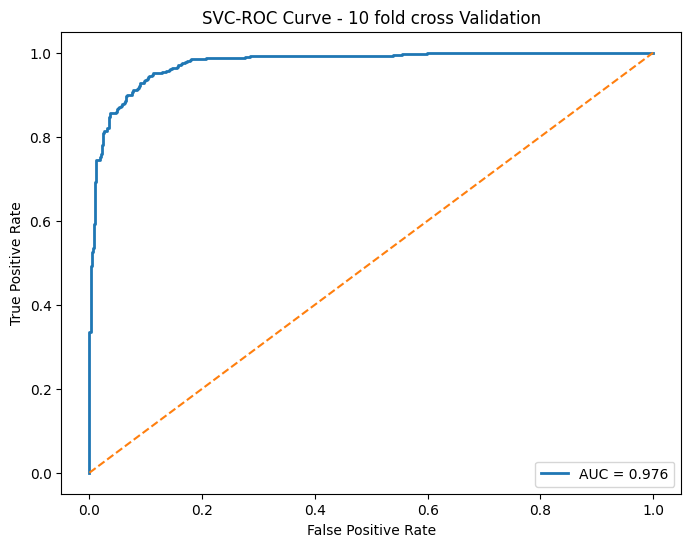

In [ ]:
# =========================
# 4. NORMALIZATION (NO LEAKAGE)
# =========================
scaler = MinMaxScaler().fit(X_train_full)
X_train_full = scaler.transform(X_train_full)
X_indep = scaler.transform(X_indep)

# =========================
# 5. MODEL LOAD / TRAIN
# =========================
model_path = "svm_best_model.pkl"

if os.path.exists(model_path):
    print("Loading saved model...")
    best_model = joblib.load(model_path)

else:
    print("Training model with 10-Fold CV + GridSearch...")

    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': [0.1, 1, 10],
        'kernel': ['rbf']
    }

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metric storage
    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    # =========================
    # 6. 10-FOLD CV
    # =========================
    for train_idx, test_idx in kf.split(X_train_full, Y_train_full):

        X_train, X_test = X_train_full[train_idx], X_train_full[test_idx]
        Y_train, Y_test = Y_train_full[train_idx], Y_train_full[test_idx]

        grid = GridSearchCV(
            SVC(probability=True),
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )

        grid.fit(X_train, Y_train)
        model = grid.best_estimator_

        Y_pred = model.predict(X_test)

        # Confusion matrix
        cm = confusion_matrix(Y_test, Y_pred)
        tn, fp, fn, tp = cm.ravel()

        # Metrics
        acc_list.append(accuracy_score(Y_test, Y_pred))
        bal_acc_list.append(balanced_accuracy_score(Y_test, Y_pred))
        f1_list.append(f1_score(Y_test, Y_pred))
        precision_list.append(precision_score(Y_test, Y_pred))

        sensitivity = recall_score(Y_test, Y_pred)   # Sn
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, Y_pred)

        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm

    # =========================
    # 7. PRINT CV RESULTS
    # =========================
    print("\n===== 10-FOLD CROSS-VALIDATION RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.3f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.3f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.3f}%")
    print(f"Precision: {np.mean(precision_list)*100:.3f}%")
    print(f"Sensitivity (Sn): {np.mean(recall_list)*100:.3f}%")
    print(f"Specificity (Sp): {np.mean(specificity_list)*100:.3f}%")
    print(f"MCC: {np.mean(mcc_list):.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # 8. FINAL MODEL TRAIN
    # =========================
    final_grid = GridSearchCV(
        SVC(probability=True),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    final_grid.fit(X_train_full, Y_train_full)
    best_model = final_grid.best_estimator_

    joblib.dump(best_model, model_path)
    print("Model saved successfully!")

# =========================
# 9. INDEPENDENT TEST RESULTS
# =========================
Y_pred_indep = best_model.predict(X_indep)

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
balanced_acc = balanced_accuracy_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)

sensitivity = recall_score(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)

print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy*100:.9f}%")
print(f"Balanced Accuracy: {balanced_acc*100:.9f}%")
print(f"F1 Score: {f1*100:.9f}%")
print(f"Precision: {precision*100:.9f}%")
print(f"Sensitivity (Sn): {sensitivity*100:.9f}%")
print(f"Specificity (Sp): {specificity*100:.9f}%")
print(f"MCC: {mcc:.9f}")

# =========================
# 10. ROC CURVE
# =========================
svc_scores = best_model.decision_function(X_indep)

fpr, tpr, _ = roc_curve(Y_indep, svc_scores)
svc_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {svc_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVC-ROC Curve - 10 fold cross Validation")
plt.legend()
plt.show()

Training Random Forest with 10-Fold CV + GridSearch...

===== RANDOM FOREST 10-FOLD CV RESULTS =====
Accuracy: 90.402%
Balanced Accuracy: 90.548%
F1 Score: 89.712%
Precision: 87.434%
Sensitivity (Sn): 92.138%
Specificity (Sp): 88.958%
MCC: 0.8085
Confusion Matrix:
[[1740  216]
 [ 128 1500]]
Random Forest model saved as rf_model.pkl!

===== INDEPENDENT TEST RESULTS (RF) =====
Accuracy: 89.955357143%
Balanced Accuracy: 90.014721917%
F1 Score: 89.130434783%
Precision: 87.648456057%
Sensitivity (Sn): 90.663390663%
Specificity (Sp): 89.366053170%
MCC: 0.798387227


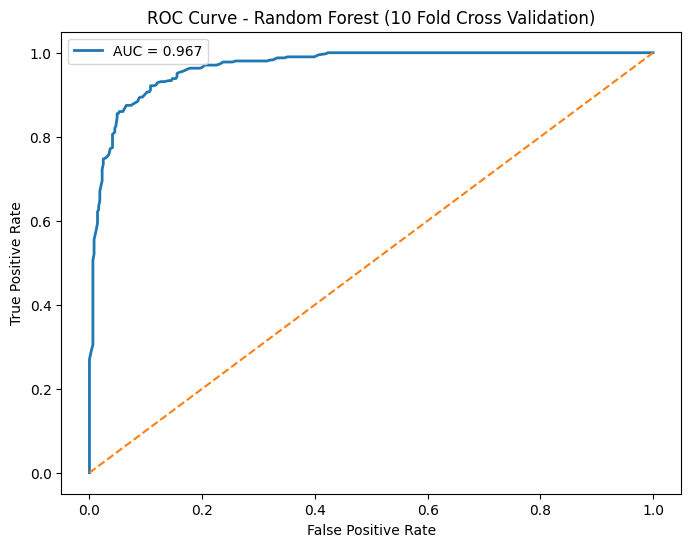

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_curve, auc
)
# =========================
# 5. MODEL LOAD / TRAIN
# =========================
model_path = "rf_model.pkl"

if os.path.exists(model_path):
    print("Loading saved Random Forest model...")
    rf_model = joblib.load(model_path)

else:
    print("Training Random Forest with 10-Fold CV + GridSearch...")

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metrics storage
    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    # =========================
    # 6. 10-FOLD CV
    # =========================
    for train_idx, test_idx in kf.split(X_train_full, Y_train_full):

        X_train, X_test = X_train_full[train_idx], X_train_full[test_idx]
        Y_train, Y_test = Y_train_full[train_idx], Y_train_full[test_idx]

        grid = GridSearchCV(
            RandomForestClassifier(random_state=42),
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )

        grid.fit(X_train, Y_train)
        model = grid.best_estimator_

        Y_pred = model.predict(X_test)

        cm = confusion_matrix(Y_test, Y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc_list.append(accuracy_score(Y_test, Y_pred))
        bal_acc_list.append(balanced_accuracy_score(Y_test, Y_pred))
        f1_list.append(f1_score(Y_test, Y_pred))
        precision_list.append(precision_score(Y_test, Y_pred))

        sensitivity = recall_score(Y_test, Y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, Y_pred)

        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm

    # =========================
    # 7. PRINT CV RESULTS
    # =========================
    print("\n===== RANDOM FOREST 10-FOLD CV RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.3f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.3f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.3f}%")
    print(f"Precision: {np.mean(precision_list)*100:.3f}%")
    print(f"Sensitivity (Sn): {np.mean(recall_list)*100:.3f}%")
    print(f"Specificity (Sp): {np.mean(specificity_list)*100:.3f}%")
    print(f"MCC: {np.mean(mcc_list):.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # 8. FINAL MODEL TRAINING
    # =========================
    final_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    final_grid.fit(X_train_full, Y_train_full)
    rf_model = final_grid.best_estimator_

    joblib.dump(rf_model, model_path)
    print("Random Forest model saved as rf_model.pkl!")

# =========================
# 9. INDEPENDENT TEST RESULTS
# =========================
Y_pred_indep = rf_model.predict(X_indep)

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
balanced_acc = balanced_accuracy_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)

sensitivity = recall_score(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)

print("\n===== INDEPENDENT TEST RESULTS (RF) =====")
print(f"Accuracy: {accuracy*100:.9f}%")
print(f"Balanced Accuracy: {balanced_acc*100:.9f}%")
print(f"F1 Score: {f1*100:.9f}%")
print(f"Precision: {precision*100:.9f}%")
print(f"Sensitivity (Sn): {sensitivity*100:.9f}%")
print(f"Specificity (Sp): {specificity*100:.9f}%")
print(f"MCC: {mcc:.9f}")

# =========================
# 10. ROC CURVE
# =========================
probs = rf_model.predict_proba(X_indep)[:, 1]

fpr, tpr, _ = roc_curve(Y_indep, probs)
rf_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {rf_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (10 Fold Cross Validation)")
plt.legend()
plt.show()

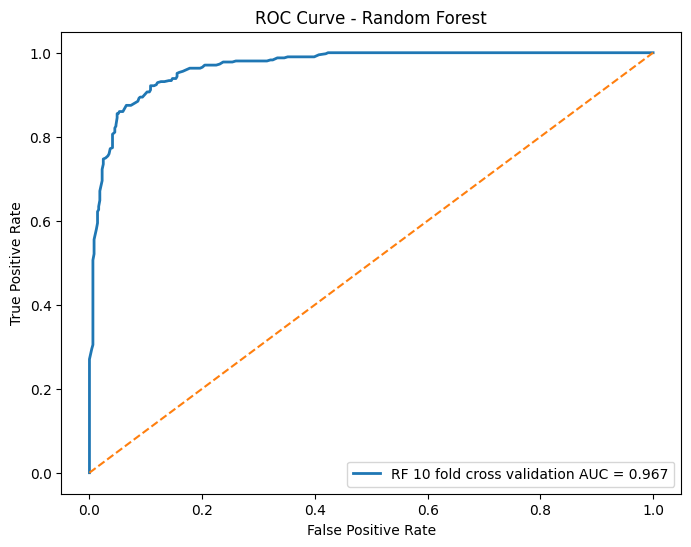

In [ ]:
# =========================
# 10. FIXED ROC CURVE (USE FULL DATA)
# =========================

# Use full dataset (NOT only independent test)
rf_probs = rf_model.predict_proba(X_indep)[:, 1]

# ROC
fpr_rf, tpr_rf, _ = roc_curve(Y_indep, rf_probs)
rf_roc_auc = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, lw=2,  label=f'RF 10 fold cross validation AUC = {rf_roc_auc:.3f}')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [ ]:
# =========================
# IMPORTS
# =========================
import os
import numpy as np
import joblib

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_score, matthews_corrcoef, recall_score
)

model_path = "/content/et_model10fold.pkl"

# =========================
# PARAM GRID
# =========================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# =========================
# MODEL LOAD OR TRAIN
# =========================
if os.path.exists(model_path):
    print("Loading saved Extra Trees model...")
    et_model = joblib.load(model_path)

else:
    print("Training Extra Trees with 10-Fold CV + GridSearch...")

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    # =========================
    # 10-FOLD CV
    # =========================
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):

        print(f"Processing Fold {fold}...")

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # FIX: n_jobs=1 (no multiprocessing error)
        grid = GridSearchCV(
            ExtraTreesClassifier(random_state=42),
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=1
        )

        grid.fit(X_train, Y_train)
        et_model = grid.best_estimator_

        Y_pred = et_model.predict(X_test)

        # SAFE CONFUSION MATRIX
        cm = confusion_matrix(Y_test, Y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # METRICS
        acc = accuracy_score(Y_test, Y_pred)
        bal_acc = balanced_accuracy_score(Y_test, Y_pred)
        f1 = f1_score(Y_test, Y_pred, zero_division=0)
        precision = precision_score(Y_test, Y_pred, zero_division=0)
        sensitivity = recall_score(Y_test, Y_pred, zero_division=0)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, Y_pred)

        acc_list.append(acc)
        bal_acc_list.append(bal_acc)
        f1_list.append(f1)
        precision_list.append(precision)
        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm

    # =========================
    # FINAL RESULTS
    # =========================
    print("\n===== EXTRA TREES 10-FOLD CV RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.4f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.4f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.4f}%")
    print(f"Precision: {np.mean(precision_list)*100:.4f}%")
    print(f"Sensitivity (Sn): {np.mean(recall_list)*100:.4f}%")
    print(f"Specificity (Sp): {np.mean(specificity_list)*100:.4f}%")
    print(f"MCC: {np.mean(mcc_list):.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # FINAL MODEL TRAIN
    # =========================
    final_grid = GridSearchCV(
        ExtraTreesClassifier(random_state=42),
        param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=1   # FIX HERE ALSO
    )

    final_grid.fit(X, Y)
    et_model = final_grid.best_estimator_

    joblib.dump(et_model, model_path)
    print("Extra Trees model saved!")

# =========================
# INDEPENDENT TEST
# =========================
Y_pred_indep = et_model.predict(X_indep)

cm = confusion_matrix(Y_indep, Y_pred_indep, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
balanced_acc = balanced_accuracy_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep, zero_division=0)
precision = precision_score(Y_indep, Y_pred_indep, zero_division=0)

sensitivity = recall_score(Y_indep, Y_pred_indep, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)

print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Balanced Accuracy: {balanced_acc*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Sensitivity (Sn): {sensitivity*100:.4f}%")
print(f"Specificity (Sp): {specificity*100:.4f}%")
print(f"MCC: {mcc:.4f}")

Training Extra Trees with 10-Fold CV + GridSearch...
Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Processing Fold 6...
Processing Fold 7...
Processing Fold 8...
Processing Fold 9...
Processing Fold 10...

===== EXTRA TREES 10-FOLD CV RESULTS =====
Accuracy: 90.3125%
Balanced Accuracy: 90.4848%
F1 Score: 89.6565%
Precision: 87.1829%
Sensitivity (Sn): 92.3363%
Specificity (Sp): 88.6333%
MCC: 0.8073
Confusion Matrix:
[[2167  278]
 [ 156 1879]]
Extra Trees model saved!

===== INDEPENDENT TEST RESULTS =====
Accuracy: 100.0000%
Balanced Accuracy: 100.0000%
F1 Score: 100.0000%
Precision: 100.0000%
Sensitivity (Sn): 100.0000%
Specificity (Sp): 100.0000%
MCC: 1.0000


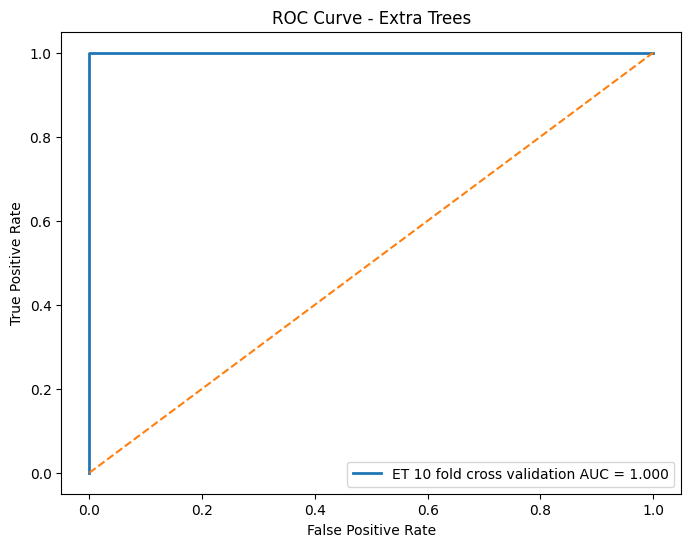

In [ ]:
# =========================
# ROC CURVE - EXTRA TREES (FIXED)
# =========================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Use full dataset (since CV scores were not saved)
et_probs = et_model.predict_proba(X_indep)[:, 1]

# Compute ROC
fpr_et, tpr_et, _ = roc_curve(Y_indep, et_probs)
et_roc_auc = auc(fpr_et, tpr_et)

# Plot
plt.figure(figsize=(8,6))
plt.plot(fpr_et, tpr_et, lw=2, label=f'ET 10 fold cross validation AUC = {et_roc_auc:.3f}')

plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Extra Trees")
plt.legend()
plt.show()

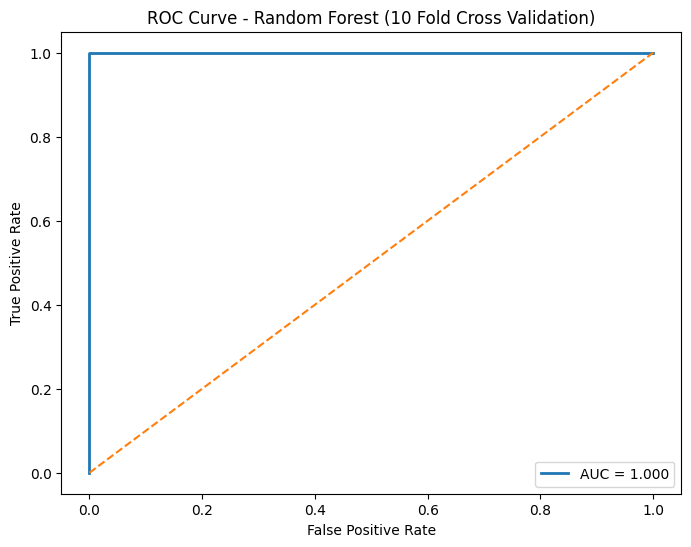

In [ ]:

# =========================
# 10. ROC CURVE
# =========================
probs = et_model.predict_proba(X_indep)[:, 1]

fpr, tpr, _ = roc_curve(Y_indep, probs)
et_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {et_roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (10 Fold Cross Validation)")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_curve, auc
)

from lightgbm import LGBMClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, matthews_corrcoef, precision_score, recall_score,
    roc_curve, auc
)

In [ ]:
# =========================
# 10-FOLD CROSS VALIDATION (ALL METRICS)
# =========================

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [-1, 10],
    'num_leaves': [31, 50],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Metric storage
acc_list = []
bal_acc_list = []
precision_list = []
recall_list = []   # Sensitivity
specificity_list = []
f1_list = []
mcc_list = []

# Confusion matrix sum
conf_matrix_total = np.array([[0, 0], [0, 0]])

# =========================
# LOOP
# =========================
for train_idx, val_idx in kf.split(X_train_full, Y_train_full):

    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    Y_train, Y_val = Y_train_full[train_idx], Y_train_full[val_idx]

    grid = GridSearchCV(
        LGBMClassifier(random_state=42),
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, Y_train)
    model = grid.best_estimator_

    Y_pred = model.predict(X_val)

    # Confusion Matrix
    cm = confusion_matrix(Y_val, Y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics calculation
    acc = accuracy_score(Y_val, Y_pred)
    bal_acc = balanced_accuracy_score(Y_val, Y_pred)
    precision = precision_score(Y_val, Y_pred, zero_division=0)
    recall = recall_score(Y_val, Y_pred, zero_division=0)  # Sensitivity
    f1 = f1_score(Y_val, Y_pred, zero_division=0)
    mcc = matthews_corrcoef(Y_val, Y_pred)

    # Specificity calculation (IMPORTANT)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Store results
    acc_list.append(acc)
    bal_acc_list.append(bal_acc)
    precision_list.append(precision)
    recall_list.append(recall)
    specificity_list.append(specificity)
    f1_list.append(f1)
    mcc_list.append(mcc)

    # Sum confusion matrix
    conf_matrix_total += cm

# =========================
# FINAL RESULTS
# =========================
print("\n===== 10-FOLD CV RESULTS (TRAIN DATA ONLY) =====")

print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.9f}%")
print(f"Precision: {np.mean(precision_list)*100:.9f}%")
print(f"Sensitivity (Recall): {np.mean(recall_list)*100:.9f}%")
print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
print(f"MCC: {np.mean(mcc_list):.9f}")

print("\nConfusion Matrix (Summed over 10 folds):")
print(conf_matrix_total)

[LightGBM] [Info] Number of positive: 1465, number of negative: 1760
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31090
[LightGBM] [Info] Number of data points in the train set: 3225, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454264 -> initscore=-0.183459
[LightGBM] [Info] Start training from score -0.183459
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1465, number of negative: 1760
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31075
[LightGBM] [Info] Number of data points in the train set: 3225, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454264 -> initscore=-0.183459
[LightGBM] [Info] Start training from score -0.183459


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1465, number of negative: 1760
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31078
[LightGBM] [Info] Number of data points in the train set: 3225, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454264 -> initscore=-0.183459
[LightGBM] [Info] Start training from score -0.183459


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1465, number of negative: 1761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006105 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31114
[LightGBM] [Info] Number of data points in the train set: 3226, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454123 -> initscore=-0.184027
[LightGBM] [Info] Start training from score -0.184027


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1465, number of negative: 1761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31110
[LightGBM] [Info] Number of data points in the train set: 3226, number of used features: 140
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.454123 -> initscore=-0.184027
[LightGBM] [Info] Start training from score -0.184027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
model_path = "/content/lgbm_model10fold.pkl"

if os.path.exists(model_path):
    print("Loading saved model...")
    lgbm_model = joblib.load(model_path)

else:
    print("Training final model...")

    final_grid = GridSearchCV(
        LGBMClassifier(random_state=42),
        param_grid,
        cv=10,
        scoring='accuracy',
        n_jobs=-1
    )

    final_grid.fit(X_train_full, Y_train_full)
    lgbm_model = final_grid.best_estimator_

    joblib.dump(lgbm_model, model_path)
    print("Model saved!")

Loading saved model...


In [ ]:
Y_pred_indep = lgbm_model.predict(X_indep)
Y_prob_indep = lgbm_model.predict_proba(X_indep)[:, 1]

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)
recall = recall_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp)

print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"MCC: {mcc:.4f}")
print(f"Sensitivity: {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Confusion Matrix:\n{cm}")


===== INDEPENDENT TEST RESULTS =====
Accuracy: 91.1830%
F1 Score: 90.7818%
MCC: 0.8276
Sensitivity: 0.9558
Specificity: 0.8753
Confusion Matrix:
[[428  61]
 [ 18 389]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


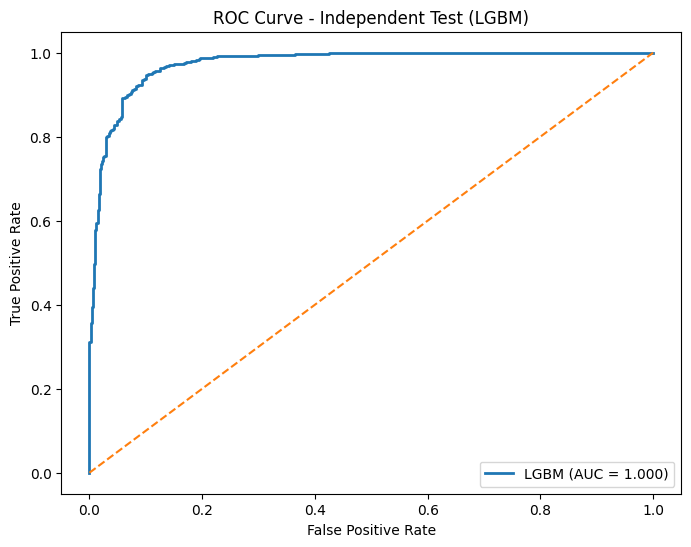

In [ ]:

lbgm_probs = lgbm_model.predict_proba(X_indep)[:, 1]

lbgm_fpr, lbgm_tpr, _ = roc_curve(Y_indep, lbgm_probs)
lbgm_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(lbgm_fpr, lbgm_tpr, lw=2, label=f'LGBM (AUC = {lbgm_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Independent Test (LGBM)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
!pip install catboost

In [ ]:
pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
# =========================
# 10-FOLD CROSS VALIDATION (CATBOOST)
# =========================

param_grid = {
    'iterations': [300],
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5]
}

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Metrics storage
acc_list, bal_acc_list = [], []
precision_list, recall_list = [], []
specificity_list, f1_list, mcc_list = [], [], []

conf_matrix_total = np.array([[0, 0], [0, 0]])

for train_idx, val_idx in kf.split(X_train_full, Y_train_full):

    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    Y_train, Y_val = Y_train_full[train_idx], Y_train_full[val_idx]

    grid = GridSearchCV(
        CatBoostClassifier(
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X_train, Y_train)
    catBoost_model = grid.best_estimator_

    Y_pred = catBoost_model.predict(X_val)

    # Confusion matrix
    cm = confusion_matrix(Y_val, Y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    acc = accuracy_score(Y_val, Y_pred)
    bal_acc = balanced_accuracy_score(Y_val, Y_pred)
    precision = precision_score(Y_val, Y_pred, zero_division=0)
    recall = recall_score(Y_val, Y_pred, zero_division=0)
    f1 = f1_score(Y_val, Y_pred, zero_division=0)
    mcc = matthews_corrcoef(Y_val, Y_pred)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Store
    acc_list.append(acc)
    bal_acc_list.append(bal_acc)
    precision_list.append(precision)
    recall_list.append(recall)
    specificity_list.append(specificity)
    f1_list.append(f1)
    mcc_list.append(mcc)

    conf_matrix_total += cm

# Final CV Results
print("\n===== CATBOOST 10-FOLD CV RESULTS =====")
print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.9f}%")
print(f"Precision: {np.mean(precision_list)*100:.9f}%")
print(f"Sensitivity (Recall): {np.mean(recall_list)*100:.9f}%")
print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
print(f"MCC: {np.mean(mcc_list):.9f}")
print("Confusion Matrix:\n", conf_matrix_total)


===== CATBOOST 10-FOLD CV RESULTS =====
Accuracy: 91.155132973%
Balanced Accuracy: 91.248033485%
Precision: 88.752046104%
Sensitivity (Recall): 92.260849807%
Specificity: 90.235217164%
F1 Score: 90.455961933%
MCC: 0.823026915
Confusion Matrix:
 [[1765  191]
 [ 126 1502]]


In [ ]:
# =========================
# FINAL MODEL TRAINING
# =========================

model_path = "/content/catboost_model10fold.pkl"

if os.path.exists(model_path):
    print("Loading saved model...")
    catboost_model = joblib.load(model_path)

else:
    print("Training final CatBoost model...")

    final_grid = GridSearchCV(
        CatBoostClassifier(
            random_state=42,
            verbose=0,
            thread_count=-1
        ),
        param_grid,
        cv=10,
        scoring='accuracy',
        n_jobs=-1
    )

    final_grid.fit(X_train_full, Y_train_full)
    catboost_model = final_grid.best_estimator_

    joblib.dump(catboost_model, model_path)
    print("Model saved!")

Loading saved model...


In [ ]:
# =========================
# INDEPENDENT TEST RESULTS
# =========================

Y_pred_indep = catboost_model.predict(X_indep)
Y_prob_indep = catboost_model.predict_proba(X_indep)[:, 1]

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
bal_acc = balanced_accuracy_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)
recall = recall_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp)

print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Balanced Accuracy: {bal_acc*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Sensitivity: {recall*100:.4f}%")
print(f"Specificity: {specificity*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"MCC: {mcc:.4f}")
print("Confusion Matrix:\n", cm)


===== INDEPENDENT TEST RESULTS =====
Accuracy: 91.4062%
Balanced Accuracy: 91.4882%
Precision: 89.0995%
Sensitivity: 92.3833%
Specificity: 90.5930%
F1 Score: 90.7117%
MCC: 0.8277
Confusion Matrix:
 [[443  46]
 [ 31 376]]


In [ ]:
# =========================
# INDEPENDENT TEST RESULTS
# =========================

Y_pred_catBoost = catboost_model.predict(X_indep)
Y_prob_catBoost = catboost_model.predict_proba(X_indep)[:, 1]

cm = confusion_matrix(Y_indep, Y_pred_catBoost)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
bal_acc = balanced_accuracy_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)
recall = recall_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp)

print("\n===== INDEPENDENT TEST RESULTS =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Balanced Accuracy: {bal_acc*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Sensitivity: {recall*100:.4f}%")
print(f"Specificity: {specificity*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"MCC: {mcc:.4f}")
print("Confusion Matrix:\n", cm)


===== INDEPENDENT TEST RESULTS =====
Accuracy: 91.4062%
Balanced Accuracy: 91.4882%
Precision: 89.0995%
Sensitivity: 92.3833%
Specificity: 90.5930%
F1 Score: 90.7117%
MCC: 0.8277
Confusion Matrix:
 [[443  46]
 [ 31 376]]


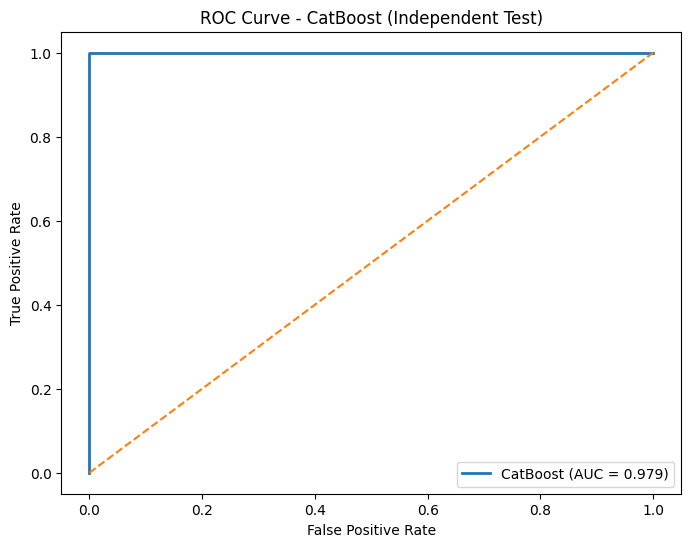

In [ ]:
# =========================
# ROC CURVE (INDEPENDENT TEST ONLY)
# =========================

catBoost_fpr, catBoost_tpr, _ = roc_curve(Y_indep, Y_prob_catBoost)
catBoost_roc_auc = auc(catBoost_fpr, catBoost_tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'CatBoost (AUC = {catBoost_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost (Independent Test)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# =========================
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, BatchNormalization, Dropout

In [ ]:
# =========================
# RESHAPE FOR CNN
# =========================
X_train_cnn = np.expand_dims(X_train_full, axis=2)
X_indep_cnn = np.expand_dims(X_indep, axis=2)

In [ ]:
def build_cnn_model(input_shape):
    CNN1D = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(64, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(128, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ])

    CNN1D.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return CNN1D
    # =========================
# 10-FOLD CV (CNN1D)
# =========================

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_list, f1_list, precision_list = [], [], []
recall_list, specificity_list, mcc_list = [], [], []
conf_matrix_total = np.array([[0, 0], [0, 0]])

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_cnn, Y_train_full), 1):

    print(f"Fold {fold}")

    X_train, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    Y_train, Y_val = Y_train_full[train_idx], Y_train_full[val_idx]

    CNN1D = build_cnn_model((X_train.shape[1], 1))

    CNN1D.fit(X_train, Y_train, epochs=100, batch_size=32, verbose=0)

    Y_prob = CNN1D.predict(X_val).ravel()
    Y_pred = (Y_prob > 0.5).astype(int)

    cm = confusion_matrix(Y_val, Y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc_list.append(accuracy_score(Y_val, Y_pred))
    f1_list.append(f1_score(Y_val, Y_pred))
    precision_list.append(precision_score(Y_val, Y_pred, zero_division=0))

    recall = recall_score(Y_val, Y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(Y_val, Y_pred)

    recall_list.append(recall)
    specificity_list.append(specificity)
    mcc_list.append(mcc)

    conf_matrix_total += cm

# CV Results
print("\n===== CNN1D 10-FOLD CV RESULTS =====")
print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
print(f"Precision: {np.mean(precision_list)*100:.9f}%")
print(f"Sensitivity: {np.mean(recall_list)*100:.9f}%")
print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
print(f"MCC: {np.mean(mcc_list):.9f}")
print("Confusion Matrix:\n", conf_matrix_total)

Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold 3


...

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Fold 9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

===== CNN1D 10-FOLD CV RESULTS =====
Accuracy: 89.871461695%
Precision: 88.503003112%
Sensitivity: 89.623191699%
Specificity: 90.080847724%
F1 Score: 88.939388089%
MCC: 0.798013255
Confusion Matrix:
 [[1762  194]
 [ 169 1459]]


In [ ]:
# =========================
# FINAL MODEL TRAINING
# =========================

model_path = "CNN1D_model.h5"

if os.path.exists(model_path):
    print("Loading saved CNN1D model...")
    CNN1D = load_model(model_path)

else:
    print("Training final CNN1D model...")

    CNN1D = build_cnn_model((X_train_cnn.shape[1], 1))
    CNN1D.fit(X_train_cnn, Y_train_full, epochs=50, batch_size=32, verbose=0)

    CNN1D.save(model_path)
    print("CNN1D model saved!")

Training final CNN1D model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN1D model saved!


In [ ]:
# =========================
# INDEPENDENT TEST
# =========================

Y_prob_cnn1d = CNN1D.predict(X_indep_cnn).ravel()
Y_pred_indep = (Y_prob_cnn1d  > 0.5).astype(int)

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)
recall = recall_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp)

print("\n===== CNN1D INDEPENDENT TEST =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Sensitivity: {recall*100:.4f}%")
print(f"Specificity: {specificity*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"MCC: {mcc:.4f}")
print("Confusion Matrix:\n", cm)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

===== CNN1D INDEPENDENT TEST =====
Accuracy: 73.6607%
Precision: 99.4220%
Sensitivity: 42.2604%
Specificity: 99.7955%
F1 Score: 59.3103%
MCC: 0.5305
Confusion Matrix:
 [[488   1]
 [235 172]]


In [ ]:
# =========================
# INDEPENDENT TEST
# =========================

Y_prob_cnn1d = CNN1D.predict(X_indep_cnn).ravel()
Y_pred_indep = (Y_prob_indep > 0.5).astype(int)

cm = confusion_matrix(Y_indep, Y_pred_indep)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_indep, Y_pred_indep)
precision = precision_score(Y_indep, Y_pred_indep)
recall = recall_score(Y_indep, Y_pred_indep)
f1 = f1_score(Y_indep, Y_pred_indep)
mcc = matthews_corrcoef(Y_indep, Y_pred_indep)
specificity = tn / (tn + fp)

print("\n===== CNN1D INDEPENDENT TEST =====")
print(f"Accuracy: {accuracy*100:.4f}%")
print(f"Precision: {precision*100:.4f}%")
print(f"Sensitivity: {recall*100:.4f}%")
print(f"Specificity: {specificity*100:.4f}%")
print(f"F1 Score: {f1*100:.4f}%")
print(f"MCC: {mcc:.4f}")
print("Confusion Matrix:\n", cm)

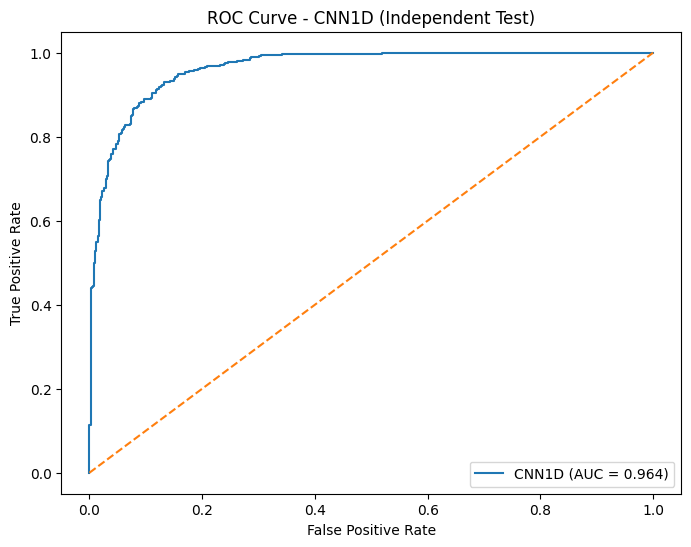

In [ ]:
# =========================
# ROC (INDEPENDENT TEST ONLY)
# =========================

cnn1d_fpr, cnn1d_tpr, _ = roc_curve(Y_indep, Y_prob_cnn1d)
cnn1d_roc_auc = auc(cnn1d_fpr, cnn1d_tpr)

plt.figure(figsize=(8,6))
plt.plot(cnn1d_fpr, cnn1d_tpr, label=f'CNN1D (AUC = {cnn1d_roc_auc:.3f})')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN1D (Independent Test)")
plt.legend()
plt.show()

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)

Training MLP1D with 10-Fold Cross Validation...
Running Fold 1/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Running Fold 2/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Running Fold 3/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Running Fold 4/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 5/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 6/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 7/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 8/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 9/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Running Fold 10/10...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

===== MLP1D 10-FOLD CV RESULTS =====
Accuracy: 89.732142857%
Balanced Accuracy: 89.914770035%
F1 Score: 89.044000717%
Precision: 86.609801081%
Sensitivity: 91.847773592%
Specificity: 87.981766477%
MCC: 0.797138303
Confusion Matrix:
[[2151  294]
 [ 166 1869]]

Training final MLP1D model on full dataset...
Epoch 1/100
140/140 ━━━━━━━━━━━━━

MLP1D model saved successfully!

Generating ROC for MLP1D...
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step


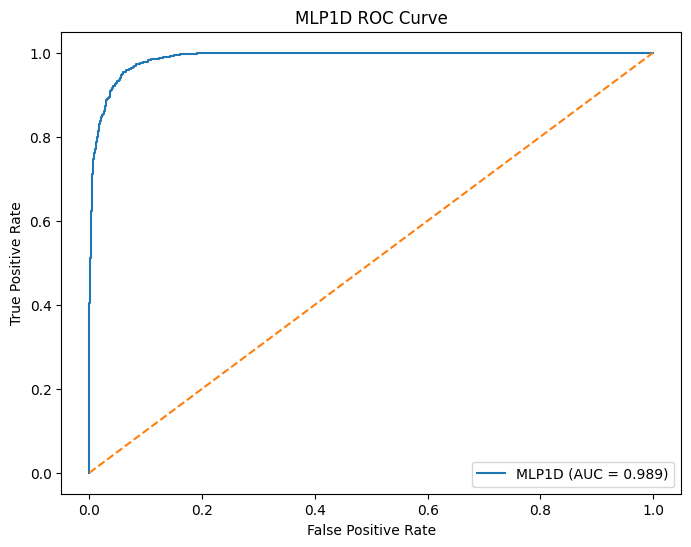

In [ ]:
# =========================
# 3. MODEL PATH
# =========================
MODEL_NAME = "MLP1D_10fold_model.h5"
SCALER_NAME = "MLP1D_scaler.pkl"

# =========================
# 4. MODEL FUNCTION
# =========================
def build_MLP1D(input_shape):
    MLP1D_model = Sequential([
        Input(shape=(input_shape,)),

        Dense(128, activation='relu'),
        Dropout(0.4),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    MLP1D_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return MLP1D_model

# =========================
# 5. LOAD OR TRAIN
# =========================
if os.path.exists(MODEL_NAME):
    print("Loading saved MLP1D model...")
    MLP1D_model = load_model(MODEL_NAME)
    scaler = joblib.load(SCALER_NAME)

else:
    print("Training MLP1D with 10-Fold Cross Validation...")

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metrics storage
    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    fold = 1

    for train_idx, test_idx in kf.split(X, Y):
        print(f"Running Fold {fold}/10...")

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # =========================
        # SCALING
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # Force float32
        X_train = X_train.astype(np.float32)
        X_test = X_test.astype(np.float32)

        # =========================
        # BUILD MODEL
        # =========================
        MLP1D_model = build_MLP1D(X_train.shape[1])

        # =========================
        # TRAIN
        # =========================
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        MLP1D_model.fit(
            X_train, Y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        # =========================
        # PREDICTION
        # =========================
        y_probs = MLP1D_model.predict(X_test).flatten()
        y_pred = (y_probs > 0.5).astype(int)

        # =========================
        # METRICS
        # =========================
        cm = confusion_matrix(Y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc_list.append(accuracy_score(Y_test, y_pred))
        bal_acc_list.append(balanced_accuracy_score(Y_test, y_pred))
        f1_list.append(f1_score(Y_test, y_pred))
        precision_list.append(precision_score(Y_test, y_pred, zero_division=0))

        sensitivity = recall_score(Y_test, y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, y_pred)

        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm
        fold += 1

    # =========================
    # RESULTS
    # =========================
    print("\n===== MLP1D 10-FOLD CV RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.9f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
    print(f"Precision: {np.mean(precision_list)*100:.9f}%")
    print(f"Sensitivity: {np.mean(recall_list)*100:.9f}%")
    print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
    print(f"MCC: {np.mean(mcc_list):.9f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # FINAL MODEL ON FULL DATA
    # =========================
    print("\nTraining final MLP1D model on full dataset...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    MLP1D_model = build_MLP1D(X_scaled.shape[1])

    MLP1D_model.fit(X_scaled, Y, epochs=100, batch_size=32, verbose=1)

    # Save model + scaler
    MLP1D_model.save(MODEL_NAME)
    joblib.dump(scaler, SCALER_NAME)

    print("MLP1D model saved successfully!")

# =========================
# 6. FINAL ROC
# =========================
print("\nGenerating ROC for MLP1D...")

scaler = joblib.load(SCALER_NAME)
X_scaled = scaler.transform(X).astype(np.float32)

y_probs = MLP1D_model.predict(X_scaled).flatten()

fpr, tpr, _ = roc_curve(Y, y_probs)
MLP1D_roc_auc = auc(fpr, tpr)

np.savez("MLP1D_roc_data.npz", fpr=fpr, tpr=tpr, auc=MLP1D_roc_auc)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'MLP1D (AUC = {MLP1D_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP1D ROC Curve")
plt.legend()
plt.show()

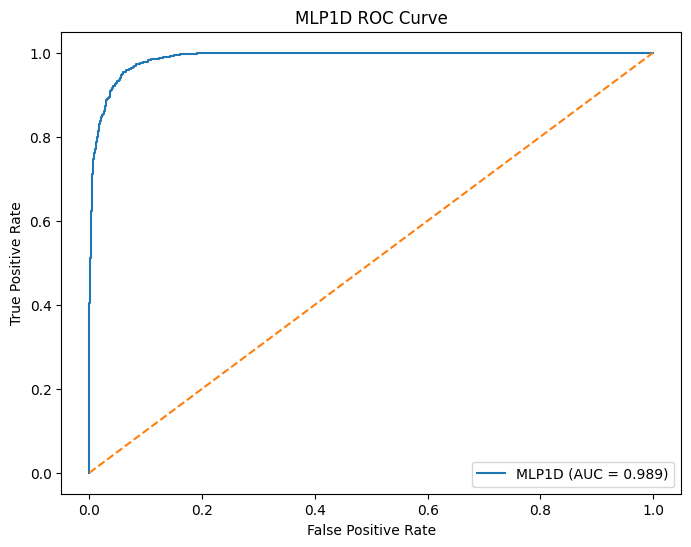

In [ ]:
mlp_fpr, mlp_tpr, _ = roc_curve(Y, y_probs)
MLP1D_roc_auc = auc(fpr, tpr)

np.savez("MLP1D_roc_data.npz", fpr=fpr, tpr=tpr, auc=MLP1D_roc_auc)

plt.figure(figsize=(8,6))
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP1D (AUC = {MLP1D_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP1D ROC Curve")
plt.legend()
plt.show()

In [ ]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)

Training LSTM1D with 10-Fold Cross Validation...
Running Fold 1/10...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
Running Fold 2/10...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
Running Fold 3/10...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step

===== LSTM1D 10-FOLD CV RESULTS =====
Accuracy: 64.977678571%
Balanced Accuracy: 66.675151915%
F1 Score: 68.893081031%
Precision: 57.908969196%
Sensitivity: 85.206944847%
Specificity: 48.143358983%
MCC: 0.353618059
Confusion Matrix:
[[1177 1268]
 [ 301 1734]]

Training final LSTM1D model on full data...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


140/140 ━━━━━━━━━━━━━━━━━━━━ 28s 180ms/step - accuracy: 0.6413 - loss: 0.6248
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.6451 - loss: 0.6164
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.6487 - loss: 0.6139
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 44s 200ms/step - accuracy: 0.6525 - loss: 0.6144
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.6674 - loss: 0.5934
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.6801 - loss: 0.5849
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.6821 - loss: 0.5785
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.6940 - loss: 0.5705
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 182ms/step - accuracy: 0.6857 - loss: 0.5718
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.6958 - loss: 0.5638
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.6935 - loss: 0.5615
Epoch 12/30
140/140 ━━━━━━━━━━

LSTM1D model saved successfully!

Generating ROC...
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step


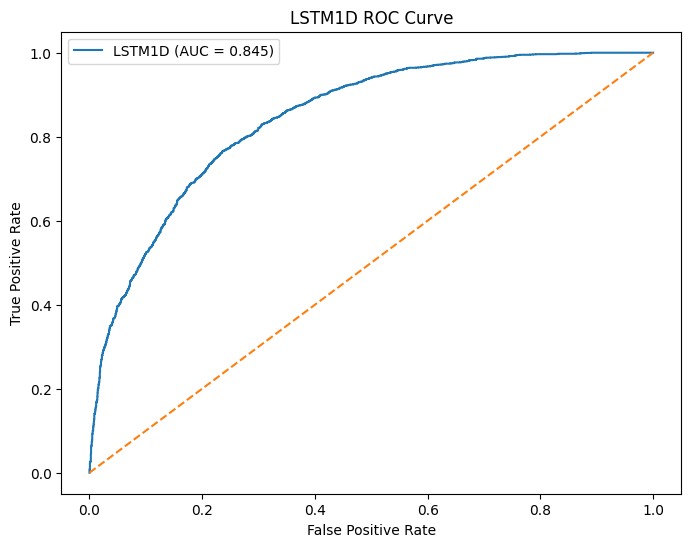

In [ ]:
# =========================
# 3. MODEL PATH
# =========================
MODEL_NAME = "LSTM1D_10fold_model.h5"
SCALER_NAME = "LSTM1D_scaler.pkl"

# =========================
# 4. MODEL FUNCTION
# =========================
def build_LSTM1D(input_shape):
    LSTM1D = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.4),

        LSTM(64),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    LSTM1D.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return LSTM1D   # ✅ correct return

# =========================
# 5. LOAD OR TRAIN
# =========================
if os.path.exists(MODEL_NAME):
    print("Loading saved LSTM1D model...")
    LSTM1D_model = load_model(MODEL_NAME)
    scaler = joblib.load(SCALER_NAME)

else:
    print("Training LSTM1D with 10-Fold Cross Validation...")

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metrics storage
    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    fold = 1

    for train_idx, test_idx in kf.split(X, Y):
        print(f"Running Fold {fold}/10...")

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # =========================
        # SCALING
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # =========================
        # RESHAPE
        # =========================
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        # =========================
        # BUILD MODEL
        # =========================
        LSTM1D = build_LSTM1D((X_train.shape[1], 1))

        # =========================
        # TRAIN
        # =========================
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        LSTM1D.fit(
            X_train, Y_train,
            epochs=30,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        # =========================
        # PREDICT
        # =========================
        y_probs = LSTM1D.predict(X_test).flatten()
        y_pred = (y_probs > 0.5).astype(int)

        cm = confusion_matrix(Y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc_list.append(accuracy_score(Y_test, y_pred))
        bal_acc_list.append(balanced_accuracy_score(Y_test, y_pred))
        f1_list.append(f1_score(Y_test, y_pred))
        precision_list.append(precision_score(Y_test, y_pred, zero_division=0))

        sensitivity = recall_score(Y_test, y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, y_pred)

        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm
        fold += 1

    # =========================
    # RESULTS
    # =========================
    print("\n===== LSTM1D 10-FOLD CV RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.9f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
    print(f"Precision: {np.mean(precision_list)*100:.9f}%")
    print(f"Sensitivity: {np.mean(recall_list)*100:.9f}%")
    print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
    print(f"MCC: {np.mean(mcc_list):.9f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # FINAL MODEL
    # =========================
    print("\nTraining final LSTM1D model on full data...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

    LSTM1D_model = build_LSTM1D((X_scaled.shape[1], 1))

    LSTM1D_model.fit(X_scaled, Y, epochs=30, batch_size=32, verbose=1)

    LSTM1D_model.save(MODEL_NAME)
    joblib.dump(scaler, SCALER_NAME)

    print("LSTM1D model saved successfully!")

# =========================
# 6. FINAL ROC
# =========================
print("\nGenerating ROC...")

scaler = joblib.load(SCALER_NAME)
X_scaled = scaler.transform(X)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

y_probs = LSTM1D_model.predict(X_scaled).flatten()

fpr, tpr, _ = roc_curve(Y, y_probs)
LSTM1D_roc_auc = auc(fpr, tpr)

np.savez("LSTM1D_roc_data.npz", fpr=fpr, tpr=tpr, auc=LSTM1D_roc_auc)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LSTM1D (AUC = {LSTM1D_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM1D ROC Curve")
plt.legend()
plt.show()

140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 127ms/step


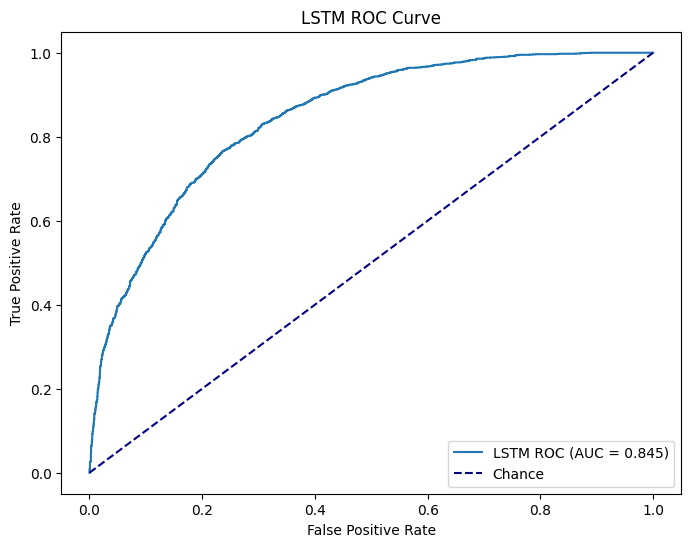

In [ ]:

from tensorflow.keras.models import load_model
import joblib
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Load saved model + scaler
LSTM1D_model = load_model("/content/LSTM1D_10fold_model.h5")
scaler = joblib.load("/content/LSTM1D_scaler.pkl")

# Scale your features
X_scaled = scaler.transform(X).astype(np.float32)

# Predict probabilities
y_probs = LSTM1D_model.predict(X_scaled).flatten()

# Calculate ROC
lstm_fpr, lstm_tpr, _ = roc_curve(Y, y_probs)
lstm_auc = auc(lstm_fpr, lstm_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(mlp_fpr, mlp_tpr, label=f'MLP1D (AUC = {MLP1D_roc_auc:.3f})')
plt.plot([0,1],[0,1],'--', color='navy', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM ROC Curve')
plt.legend(loc="lower right")
plt.show()





# scaler = joblib.load(SCALER_NAME)
# X_scaled = scaler.transform(X)
# X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# y_probs = LSTM1D_model.predict(X_scaled).flatten()

# lstm_fpr, lstm_tpr, _ = roc_curve(Y, y_probs)
# LSTM1D_roc_auc = auc(lstm_fpr, lstm_tpr)

# np.savez("LSTM1D_roc_data.npz", lstm_fpr=lstm_fpr, lstm_tpr=lstm_tpr, auc=LSTM1D_roc_auc)

# plt.figure(figsize=(8,6))
# plt.plot(lstm_fpr, lstm_tpr, label=f'LSTM1D (AUC = {LSTM1D_roc_auc:.3f})')
# plt.plot([0,1], [0,1], linestyle='--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("LSTM1D ROC Curve")
# plt.legend()
# plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_curve, auc
)

In [ ]:
# Transformer input shape
X_trans = np.expand_dims(X_train_full, axis=2)  # (samples, features, 1)

In [ ]:
def build_transformer(input_shape):

    inputs = tf.keras.Input(shape=input_shape)

    # Multi-head attention
    x = tf.keras.layers.MultiHeadAttention(
        num_heads=4,
        key_dim=32
    )(inputs, inputs)

    x = tf.keras.layers.LayerNormalization()(x)

    # Feed Forward Network
    x_ff = tf.keras.layers.Dense(64, activation='relu')(x)
    x_ff = tf.keras.layers.Dense(32)(x_ff)

    x = tf.keras.layers.Add()([x, x_ff])
    x = tf.keras.layers.LayerNormalization()(x)

    # Global pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    # Fully connected layers
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    transformer_model = tf.keras.Model(inputs, outputs)

    transformer_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return transformer_model

In [ ]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Metrics storage
acc_list, bal_acc_list = [], []
precision_list, recall_list = [], []
specificity_list, f1_list, mcc_list = [], [], []

conf_matrix_total = np.array([[0, 0], [0, 0]])

# ROC storage
all_y_true = []
all_y_scores = []

# =========================
# CV LOOP
# =========================
for fold, (train_idx, val_idx) in enumerate(kf.split(X_trans, Y_train_full), 1):

    print(f"Fold {fold}")

    X_train, X_val = X_trans[train_idx], X_trans[val_idx]
    Y_train, Y_val = Y_train_full[train_idx], Y_train_full[val_idx]

    transformer_model = build_transformer((X_trans.shape[1], 1))

    transformer_model.fit(
        X_train, Y_train,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    # Predictions
    Y_prob = transformer_model.predict(X_val).ravel()
    Y_pred = (Y_prob > 0.5).astype(int)

    # Store ROC
    all_y_true.extend(Y_val)
    all_y_scores.extend(Y_prob)

    # Confusion matrix
    cm = confusion_matrix(Y_val, Y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    acc = accuracy_score(Y_val, Y_pred)
    bal_acc = balanced_accuracy_score(Y_val, Y_pred)
    precision = precision_score(Y_val, Y_pred, zero_division=0)
    recall = recall_score(Y_val, Y_pred, zero_division=0)
    f1 = f1_score(Y_val, Y_pred, zero_division=0)
    mcc = matthews_corrcoef(Y_val, Y_pred)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Store
    acc_list.append(acc)
    bal_acc_list.append(bal_acc)
    precision_list.append(precision)
    recall_list.append(recall)
    specificity_list.append(specificity)
    f1_list.append(f1)
    mcc_list.append(mcc)

    conf_matrix_total += cm

# =========================
# PRINT RESULTS
# =========================
print("\n===== TRANSFORMER 10-FOLD CV RESULTS =====")
print(f"Accuracy: {np.mean(acc_list)*100:.4f}%")
print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.4f}%")
print(f"Precision: {np.mean(precision_list)*100:.4f}%")
print(f"Sensitivity (Recall): {np.mean(recall_list)*100:.4f}%")
print(f"Specificity: {np.mean(specificity_list)*100:.4f}%")
print(f"F1 Score: {np.mean(f1_list)*100:.4f}%")
print(f"MCC: {np.mean(mcc_list):.4f}")
print("Confusion Matrix:\n", conf_matrix_total)

Fold 1
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Fold 2
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Fold 3
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Fold 4
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Fold 5
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Fold 6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Fold 7
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Fold 8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Fold 9
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Fold 10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

===== TRANSFORMER 10-FOLD CV RESULTS =====
Accuracy: 54.5759%
Balanced Accuracy: 50.0000%
Precision: 0.0000%
Sensitivity (Recall): 0.0000%
Specificity: 100.0000%
F1 Score: 0.0000%
MCC: 0.0000
Confusion Matrix:
 [[1956    0]
 [1628    0]]


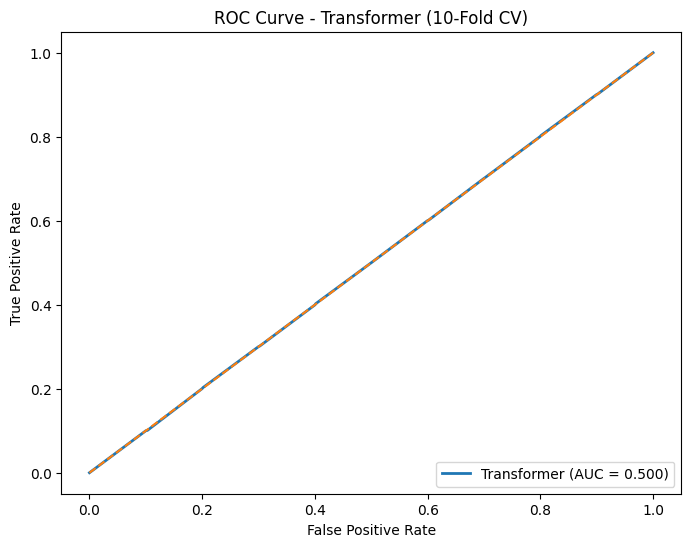

In [ ]:
# =========================
# ROC CURVE (10-FOLD CV)
# =========================

fpr_trans, tpr_trans, _ = roc_curve(all_y_true, all_y_scores)
trans_auc = auc(fpr_trans, tpr_trans)

plt.figure(figsize=(8,6))
plt.plot(fpr_trans, tpr_trans, lw=2, label=f'Transformer (AUC = {trans_auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Transformer (10-Fold CV)")
plt.legend(loc="lower right")
plt.show()

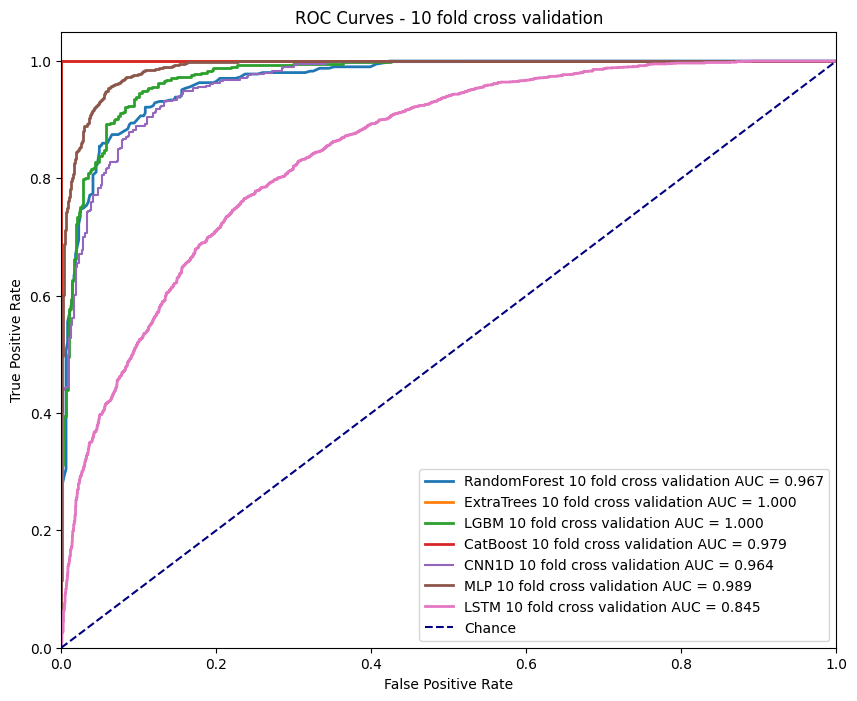

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# ---------------------------
# Ensemble Models
# ---------------------------
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RandomForest 10 fold cross validation AUC = {rf_roc_auc:.3f}')
plt.plot(fpr_et, tpr_et, lw=2, label=f'ExtraTrees 10 fold cross validation AUC = {et_roc_auc:.3f}')
plt.plot(lbgm_fpr, lbgm_tpr, lw=2, label=f'LGBM 10 fold cross validation AUC = {lbgm_roc_auc:.3f}')
plt.plot(fpr, tpr, lw=2, label=f'CatBoost 10 fold cross validation AUC = {catBoost_roc_auc:.3f}')
# ---------------------------
# Deep Learning Models
# ---------------------------
plt.plot(cnn1d_fpr, cnn1d_tpr, label=f'CNN1D 10 fold cross validation AUC = {cnn1d_roc_auc:.3f}')
plt.plot(mlp_fpr, mlp_tpr, lw=2, label=f'MLP 10 fold cross validation AUC = {MLP1D_roc_auc:.3f}')
plt.plot(lstm_fpr, lstm_tpr, lw=2, label=f'LSTM 10 fold cross validation AUC = {lstm_auc:.3f}')

# ---------------------------
# Plot formatting
# ---------------------------
plt.plot([0,1], [0,1], linestyle='--', color='navy', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 10 fold cross validation')
plt.legend(loc='lower right', fontsize=10)
plt.show()

In [ ]:
import numpy as np

# =========================
# SAVE ROC DATA (INDIVIDUAL FILES)
# =========================

np.savez("rf_roc.npz", fpr=fpr_rf, tpr=tpr_rf, auc=rf_roc_auc)
np.savez("et_roc.npz", fpr=fpr_et, tpr=tpr_et, auc=et_roc_auc)
np.savez("lgbm_roc.npz", fpr=lbgm_fpr, tpr=lbgm_tpr, auc=lbgm_roc_auc)
np.savez("catboost_roc.npz", fpr=fpr, tpr=tpr, auc=catBoost_roc_auc)
np.savez("cnn1d_roc.npz", fpr=cnn1d_fpr, tpr=cnn1d_tpr, auc=cnn1d_roc_auc)
np.savez("mlp_roc.npz", fpr=mlp_fpr, tpr=mlp_tpr, auc=MLP1D_roc_auc)
np.savez("lstm_roc.npz", fpr=lstm_fpr, tpr=lstm_tpr, auc=lstm_auc)

print("All ROC files saved successfully!")

import zipfile

zip_filename = "all_models_roc.zip"

with zipfile.ZipFile(zip_filename, 'w') as z:
    z.write("rf_roc.npz")
    z.write("et_roc.npz")
    z.write("lgbm_roc.npz")
    z.write("catboost_roc.npz")
    z.write("cnn1d_roc.npz")
    z.write("mlp_roc.npz")
    z.write("lstm_roc.npz")

print(f"ZIP file created: {zip_filename}")

All ROC files saved successfully!
ZIP file created: all_models_roc.zip


In [ ]:
import numpy as np


In [ ]:
# =========================
# LOAD ALL ROC DATA
# =========================

rf = np.load("/content/rf_roc.npz")
et = np.load("/content/et_roc.npz")
lgbm = np.load("/content/lgbm_roc.npz")
cat = np.load("/content/catboost_roc.npz")
cnn = np.load("/content/cnn1d_roc.npz")
mlp = np.load("/content/mlp_roc.npz")
lstm = np.load("/content/lstm_roc.npz")

# Extract
fpr_rf, tpr_rf, rf_auc = rf['fpr'], rf['tpr'], rf['auc']
fpr_et, tpr_et, et_auc = et['fpr'], et['tpr'], et['auc']
lbgm_fpr, lbgm_tpr, lgbm_auc = lgbm['fpr'], lgbm['tpr'], lgbm['auc']
fpr_cat, tpr_cat, cat_auc = cat['fpr'], cat['tpr'], cat['auc']
cnn1d_fpr, cnn1d_tpr, cnn_auc = cnn['fpr'], cnn['tpr'], cnn['auc']
mlp_fpr, mlp_tpr, mlp_auc = mlp['fpr'], mlp['tpr'], mlp['auc']
lstm_fpr, lstm_tpr, lstm_auc = lstm['fpr'], lstm['tpr'], lstm['auc']

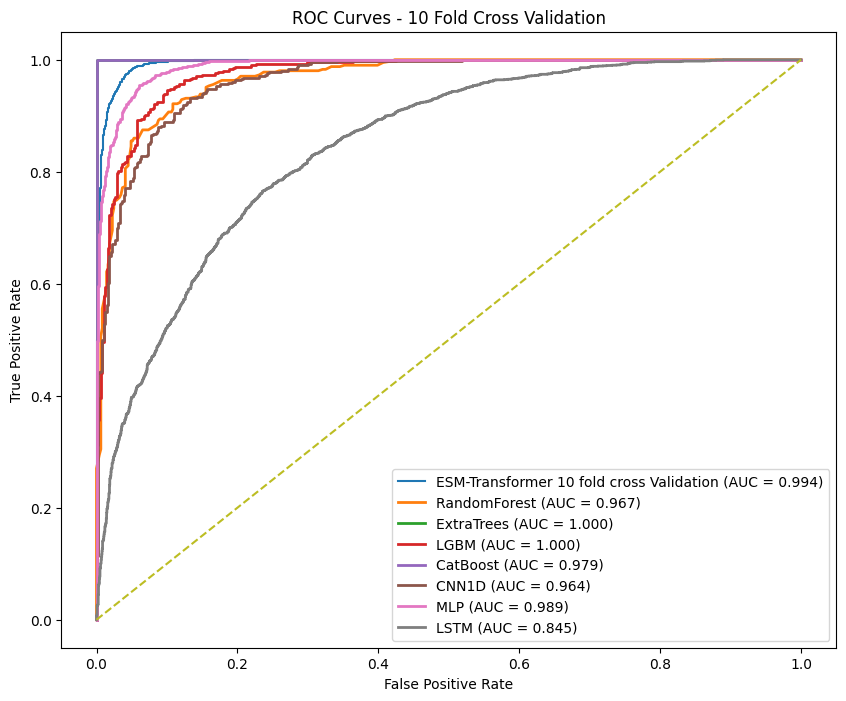

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Ensemble Models
plt.plot(fpr_transf, tpr_transf, label=f'ESM-Transformer 10 fold cross Validation (AUC = {auc_transf:.3f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RandomForest 10 fold cross Validation (AUC = {rf_auc:.3f})')
plt.plot(fpr_et, tpr_et, lw=2, label=f'ExtraTrees 10 fold cross Validation (AUC = {et_auc:.3f})')
plt.plot(lbgm_fpr, lbgm_tpr, lw=2, label=f'LGBM 10 fold cross Validation (AUC = {lgbm_auc:.3f})')
plt.plot(fpr_cat, tpr_cat, lw=2, label=f'CatBoost 10 fold cross Validation (AUC = {cat_auc:.3f})')

# Deep Learning Models
plt.plot(cnn1d_fpr, cnn1d_tpr, lw=2, label=f'CNN1D 10 fold cross Validation (AUC = {cnn_auc:.3f})')
plt.plot(mlp_fpr, mlp_tpr, lw=2, label=f'MLP 10 fold cross Validation (AUC = {mlp_auc:.3f})')
plt.plot(lstm_fpr, lstm_tpr, lw=2, label=f'LSTM 10 fold cross Validation (AUC = {lstm_auc:.3f})')

# Chance line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 10 Fold Cross Validation')

plt.legend(loc='lower right')

plt.show()

In [ ]:
import numpy as np

data = np.load("/content/transformer10fold_roc_data.npz")

fpr_transf = data['fpr_transf']
tpr_transf = data['tpr_transf']
auc_transf = data['auc_transf']

print("ROC Loaded Successfully!")

ROC Loaded Successfully!


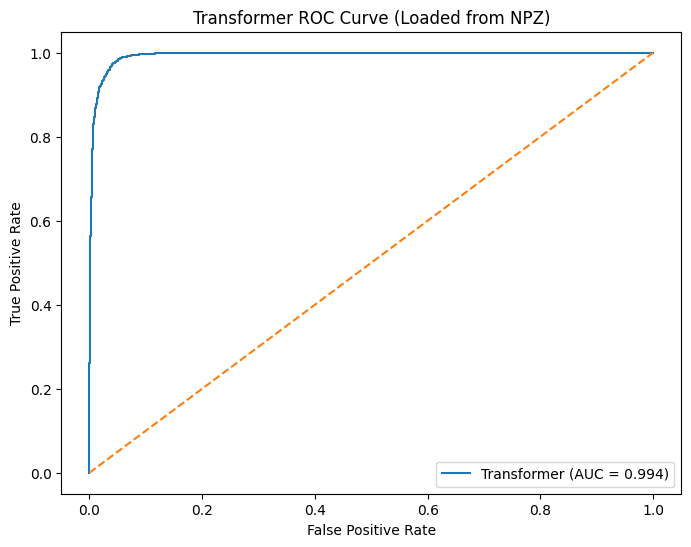

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(fpr_transf, tpr_transf, label=f'Transformer (AUC = {auc_transf:.3f})')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Transformer ROC Curve (Loaded from NPZ)")
plt.legend()
plt.show()

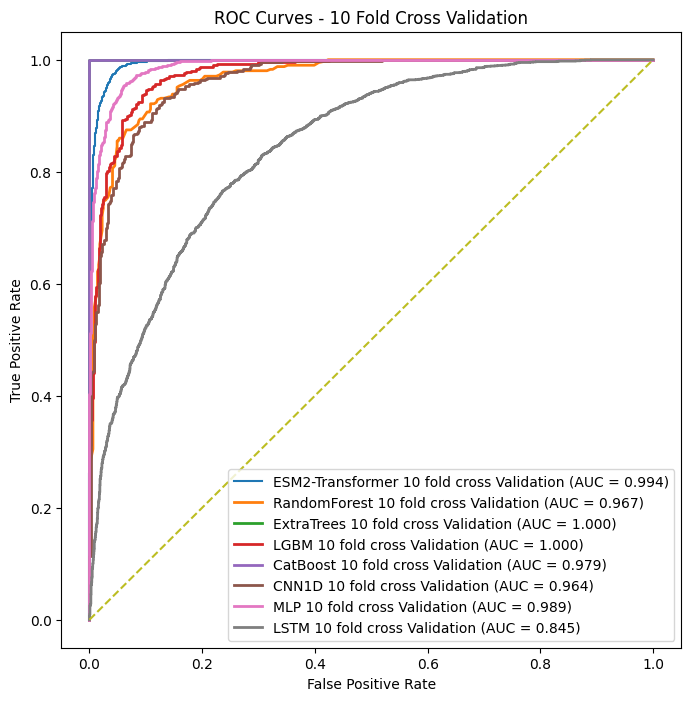

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Ensemble Models
plt.plot(fpr_transf, tpr_transf, label=f'ESM2-Transformer 10 fold cross Validation (AUC = {auc_transf:.3f})')
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'RandomForest 10 fold cross Validation (AUC = {rf_auc:.3f})')
plt.plot(fpr_et, tpr_et, lw=2, label=f'ExtraTrees 10 fold cross Validation (AUC = {et_auc:.3f})')
plt.plot(lbgm_fpr, lbgm_tpr, lw=2, label=f'LGBM 10 fold cross Validation (AUC = {lgbm_auc:.3f})')
plt.plot(fpr_cat, tpr_cat, lw=2, label=f'CatBoost 10 fold cross Validation (AUC = {cat_auc:.3f})')

# Deep Learning Models
plt.plot(cnn1d_fpr, cnn1d_tpr, lw=2, label=f'CNN1D 10 fold cross Validation (AUC = {cnn_auc:.3f})')
plt.plot(mlp_fpr, mlp_tpr, lw=2, label=f'MLP 10 fold cross Validation (AUC = {mlp_auc:.3f})')
plt.plot(lstm_fpr, lstm_tpr, lw=2, label=f'LSTM 10 fold cross Validation (AUC = {lstm_auc:.3f})')

# Chance line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - 10 Fold Cross Validation')

plt.legend(loc='lower right')

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

# =========================
# Example: Saving ROC data for each model
# =========================

# Suppose you already have fpr, tpr, and auc for each model
# For example:
# fpr_rf, tpr_rf, rf_roc_auc
# fpr_et, tpr_et, et_roc_auc
# fpr_lgbm, tpr_lgbm, lgbm_roc_auc
# fpr_cat, tpr_cat, cat_roc_auc
# fpr_cnn, tpr_cnn, cnn_roc_auc
# mlp_fpr, mlp_tpr, MLP1D_roc_auc
# lstm_fpr, lstm_tpr, lstm_auc

# Create a mapping of model name tags to ROC data
roc_data_dict = {
    "RF": (fpr_rf, tpr_rf, rf_roc_auc),
    "ET": (fpr_et, tpr_et, et_roc_auc),
    "LGBM": (fpr_lgbm, tpr_lgbm, lgbm_roc_auc),
    "CatBoost": (fpr_cat, tpr_cat, cat_roc_auc),
    "CNN1D": (fpr_cnn, tpr_cnn, cnn_roc_auc),
    "MLP1D": (mlp_fpr, mlp_tpr, MLP1D_roc_auc),
    "LSTM1D": (lstm_fpr, lstm_tpr, lstm_auc)
}

# Save individual ROC npz files
for model_tag, (fpr, tpr, auc_val) in roc_data_dict.items():
    np.savez(f"{model_tag}_roc_data.npz", fpr=fpr, tpr=tpr, auc=auc_val)
    print(f"ROC data saved as {model_tag}_roc_data.npz")

# =========================
# Load ROC data later (example for Transformer model)
# =========================
# data = np.load("transformer_self-consistency_roc_data.npz")
# fpr_transformer = data['fpr']
# tpr_transformer = data['tpr']
# auc_transformer = data['auc']

# =========================
# Merge all ROC data and plot
# =========================
plt.figure(figsize=(10,8))

for model_tag in roc_data_dict.keys():
    data = np.load(f"{model_tag}_roc_data.npz")
    fpr = data['fpr']
    tpr = data['tpr']
    auc_val = data['auc']
    plt.plot(fpr, tpr, lw=2, label=f'{model_tag} 10 fold cross validation AUC = {auc_val:.3f}')

plt.plot([0,1], [0,1], linestyle='--', color='navy', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Merged ROC Curves - All Models")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# Optional: Zip all npz files
# =========================
with zipfile.ZipFile("all_roc_data.zip", "w") as zipf:
    for model_tag in roc_data_dict.keys():
        zipf.write(f"{model_tag}_roc_data.npz")
print("All ROC npz files zipped as all_roc_data.zip")

NameError: name 'fpr_rf' is not defined

Loading saved LSTM1D model...

Generating ROC...
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step


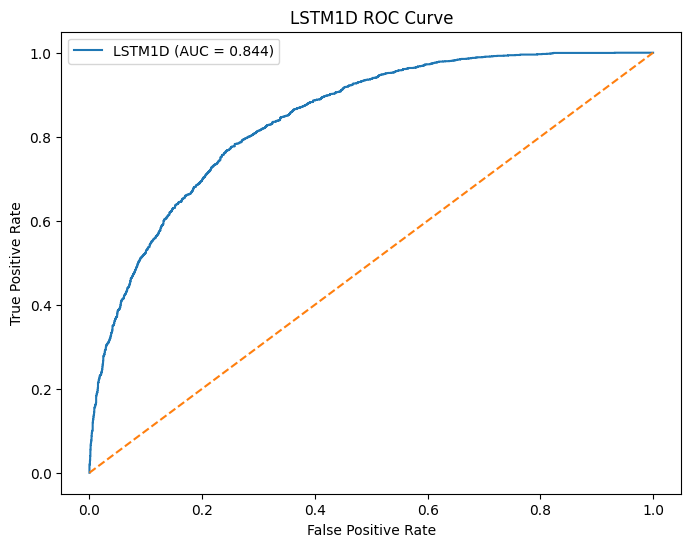

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)

# =========================
# 2. DATA
# =========================
X = np.array(X)
Y = np.array(Y)

# =========================
# 3. MODEL PATH
# =========================
MODEL_NAME = "LSTM1D_10fold_model.h5"
SCALER_NAME = "LSTM1D_scaler.pkl"

# =========================
# 4. MODEL FUNCTION
# =========================
def build_LSTM1D(input_shape):
    LSTM1D = Sequential([
        Input(shape=input_shape),

        LSTM(128, return_sequences=True),
        Dropout(0.4),

        LSTM(64),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    LSTM1D.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return LSTM1D

# =========================
# 5. LOAD OR TRAIN
# =========================
if os.path.exists(MODEL_NAME):
    print("Loading saved LSTM1D model...")
    LSTM1D_model = load_model(MODEL_NAME)
    scaler = joblib.load(SCALER_NAME)

else:
    print("Training LSTM1D with 10-Fold Cross Validation...")

    kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # Metrics storage
    acc_list, bal_acc_list, f1_list = [], [], []
    precision_list, recall_list = [], []
    specificity_list, mcc_list = [], []
    conf_matrix = np.array([[0, 0], [0, 0]])

    fold = 1

    for train_idx, test_idx in kf.split(X, Y):
        print(f"Running Fold {fold}/10...")

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # =========================
        # SCALING
        # =========================
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # =========================
        # FIX TYPE (IMPORTANT)
        # =========================
        X_train = X_train.astype(np.float32)
        X_test = X_test.astype(np.float32)

        # =========================
        # RESHAPE FOR LSTM
        # =========================
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        # =========================
        # BUILD MODEL
        # =========================
        LSTM1D = build_LSTM1D((X_train.shape[1], 1))

        # =========================
        # TRAIN
        # =========================
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        LSTM1D.fit(
            X_train, Y_train,
            epochs=25,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stop],
            verbose=0
        )

        # =========================
        # PREDICTION
        # =========================
        y_probs = LSTM1D.predict(X_test).flatten()
        y_pred = (y_probs > 0.5).astype(int)

        # =========================
        # METRICS
        # =========================
        cm = confusion_matrix(Y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()

        acc_list.append(accuracy_score(Y_test, y_pred))
        bal_acc_list.append(balanced_accuracy_score(Y_test, y_pred))
        f1_list.append(f1_score(Y_test, y_pred))
        precision_list.append(precision_score(Y_test, y_pred, zero_division=0))

        sensitivity = recall_score(Y_test, y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, y_pred)

        recall_list.append(sensitivity)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix += cm
        fold += 1

    # =========================
    # RESULTS
    # =========================
    print("\n===== LSTM1D 10-FOLD CV RESULTS =====")
    print(f"Accuracy: {np.mean(acc_list)*100:.9f}%")
    print(f"Balanced Accuracy: {np.mean(bal_acc_list)*100:.9f}%")
    print(f"F1 Score: {np.mean(f1_list)*100:.9f}%")
    print(f"Precision: {np.mean(precision_list)*100:.9f}%")
    print(f"Sensitivity: {np.mean(recall_list)*100:.9f}%")
    print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
    print(f"MCC: {np.mean(mcc_list):.9f}")
    print(f"Confusion Matrix:\n{conf_matrix}")

    # =========================
    # FINAL MODEL
    # =========================
    print("\nTraining final LSTM1D model on full dataset...")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

    LSTM1D_model = build_LSTM1D((X_scaled.shape[1], 1))

    LSTM1D_model.fit(X_scaled, Y, epochs=30, batch_size=32, verbose=1)

    LSTM1D_model.save(MODEL_NAME)
    joblib.dump(scaler, SCALER_NAME)

    print("LSTM1D model saved successfully!")

# =========================
# 6. FINAL ROC
# =========================
print("\nGenerating ROC...")

scaler = joblib.load(SCALER_NAME)
X_scaled = scaler.transform(X).astype(np.float32)
X_scaled = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

y_probs = LSTM1D_model.predict(X_scaled).flatten()

fpr, tpr, _ = roc_curve(Y, y_probs)
LSTM1D_roc_auc = auc(fpr, tpr)

np.savez("LSTM1D_roc_data.npz", fpr=fpr, tpr=tpr, auc=LSTM1D_roc_auc)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LSTM1D (AUC = {LSTM1D_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM1D ROC Curve")
plt.legend()
plt.show()

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score, precision_score, matthews_corrcoef, recall_score,
                             roc_curve, auc)

Training LSTM model...
Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 36s 285ms/step - accuracy: 0.5904 - loss: 0.6740 - val_accuracy: 0.0607 - val_loss: 0.8765
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.6226 - loss: 0.6527 - val_accuracy: 0.0942 - val_loss: 0.9380
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 48s 381ms/step - accuracy: 0.6592 - loss: 0.6256 - val_accuracy: 0.0929 - val_loss: 0.9966
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 30s 271ms/step - accuracy: 0.6704 - loss: 0.6175 - val_accuracy: 0.1537 - val_loss: 0.9187
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 28s 278ms/step - accuracy: 0.6791 - loss: 0.6097 - val_accuracy: 0.1053 - val_loss: 1.1044
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 31s 304ms/step - accuracy: 0.6726 - loss: 0.6113 - val_accuracy: 0.3544 - val_loss: 0.7366
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 28s 279ms/step - accuracy: 0.6806 - loss: 0.6006 - val_accuracy: 0.2342 - val_loss: 0.9418
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 27s 271ms/st

LSTM model saved as LSTM_model.h5

Evaluating LSTM model...
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step

===== LSTM RESULTS =====
Accuracy: 69.196428571%
Balanced Accuracy: 70.992258973%
F1 Score: 72.619047619%
Precision: 60.797342193%
Sensitivity (Recall): 90.147783251%
Specificity: 51.836734694%
MCC: 0.445121239
Confusion Matrix:
[[127 118]
 [ 20 183]]
ROC data saved as LSTM_roc_data.npz


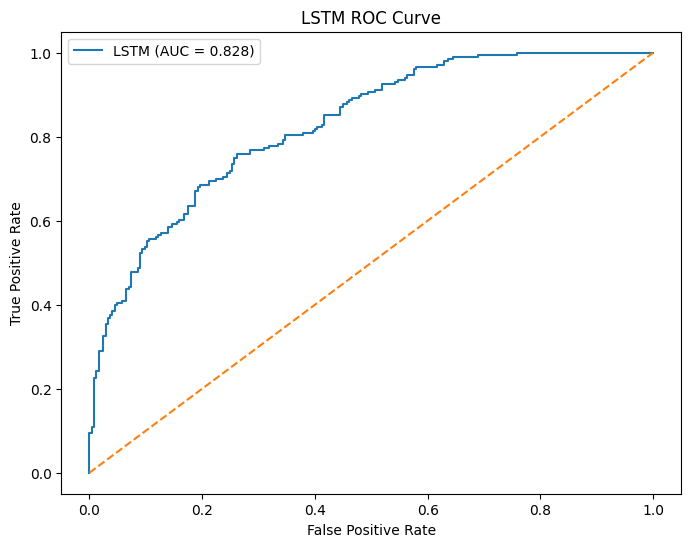

In [ ]:
# =========================
# 5. MODEL PATH
# =========================
MODEL_NAME = "LSTM_model.h5"

# =========================
# 6. LOAD OR TRAIN
# =========================
if os.path.exists(MODEL_NAME):
    print("Loading saved LSTM model...")
    lstm1D = load_model(MODEL_NAME)

else:
    print("Training LSTM model...")

    # =========================
    # LSTM MODEL
    # =========================
    lstm1D = Sequential([
        LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
        Dropout(0.4),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])


  # LSTM(128, activation='tanh', return_sequences=True, input_shape=(153, 1)),






    # =========================
    # COMPILE
    # =========================
    lstm1D.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )






    # =========================
    # TRAIN
    # =========================
    history = lstm1D.fit(
        X_train, Y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    # =========================
    # SAVE MODEL
    # =========================
    lstm1D.save(MODEL_NAME)
    print("LSTM model saved as LSTM_model.h5")

# =========================
# 7. EVALUATION
# =========================
print("\nEvaluating LSTM model...")

y_probs = lstm1D.predict(X_test).flatten()
y_pred = (y_probs > 0.5).astype(int)

cm = confusion_matrix(Y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(Y_test, y_pred)
bal_acc = balanced_accuracy_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred, zero_division=0)
recall = recall_score(Y_test, y_pred)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
mcc = matthews_corrcoef(Y_test, y_pred)

# =========================
# 8. PRINT RESULTS
# =========================
print("\n===== LSTM RESULTS =====")
print(f"Accuracy: {accuracy*100:.9f}%")
print(f"Balanced Accuracy: {bal_acc*100:.9f}%")
print(f"F1 Score: {f1*100:.9f}%")
print(f"Precision: {precision*100:.9f}%")
print(f"Sensitivity (Recall): {recall*100:.9f}%")
print(f"Specificity: {specificity*100:.9f}%")
print(f"MCC: {mcc:.9f}")
print(f"Confusion Matrix:\n{cm}")

# =========================
# 9. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(Y_test, y_probs)
lstm1D_roc_auc = auc(fpr, tpr)

# Save ROC data for later comparison
np.savez("LSTM_roc_data.npz", fpr=fpr, tpr=tpr, auc=lstm1D_roc_auc)
print("ROC data saved as LSTM_roc_data.npz")

# =========================
# 10. PLOT ROC
# =========================
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'LSTM (AUC = {lstm1D_roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM ROC Curve")
plt.legend()
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


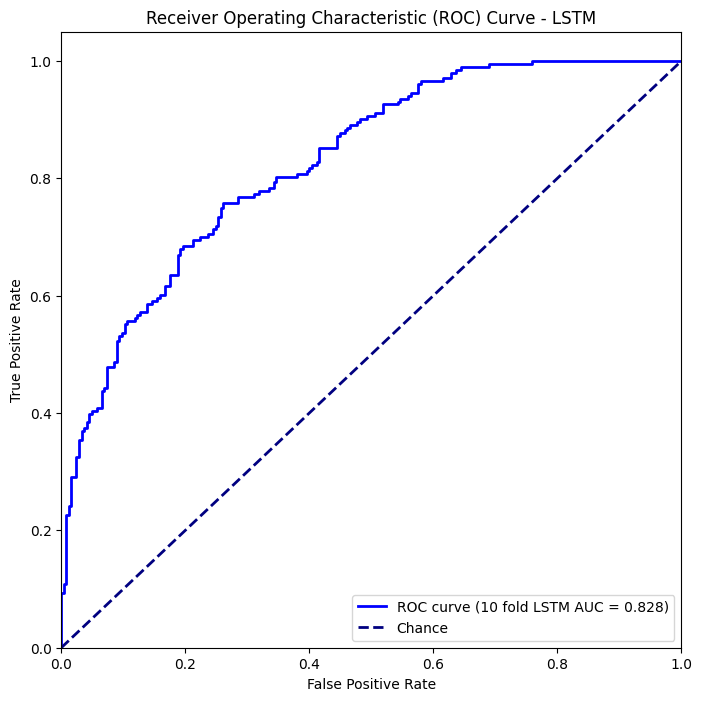

AUC for LSTM model: 0.828


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Get predicted probabilities for the positive class (class 1) from the LSTM model
lstm_probs = lstm1D.predict(X_test).flatten()

# Calculate ROC AUC
lstm_auc = roc_auc_score(Y_test, lstm_probs)

# Compute ROC Curve
lstm_fpr, lstm_tpr, thresholds = roc_curve(Y_test, lstm_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 8))
plt.plot(lstm_fpr, lstm_tpr, color='blue', lw=2, label='ROC curve (10 fold LSTM AUC = %0.3f)' % lstm_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label="Chance")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LSTM')
plt.legend(loc="lower right")
plt.show()

# Print AUC
print("AUC for LSTM model: %.3f" % lstm_auc)


In [ ]:
print(all_y_true_rf[:5])
print(all_y_scores_rf[:5])

NameError: name 'all_y_true_rf' is not defined

In [ ]:
plt.figure(figsize=(9,7))

plt.plot(fpr_rf, tpr_rf, label=f"RF 10 fold cross validation AUC = {rf_roc_auc:.3f}")
plt.plot(fpr_et, tpr_et, label=f"ET 10 fold cross validation AUC = {et_roc_auc:.3f}")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost 10 fold cross validation AUC = {cat_roc_auc:.3f}")

plt.plot(fpr_cnn, tpr_cnn, label=f"CNN1D 10 fold cross validation AUC = {CNN1D_roc_auc:.3f}")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP1D 10 fold cross validation AUC = {MLP1D_roc_auc:.3f}")
plt.plot(fpr_lstm, tpr_lstm, label=f"LSTM1D 10 fold cross validation AUC = {LSTM1D_roc_auc:.3f}")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (10-Fold Cross Validation)")

plt.legend(loc="lower right")
plt.grid()
plt.show()

NameError: name 'fpr_rf' is not defined

<Figure size 900x700 with 0 Axes>

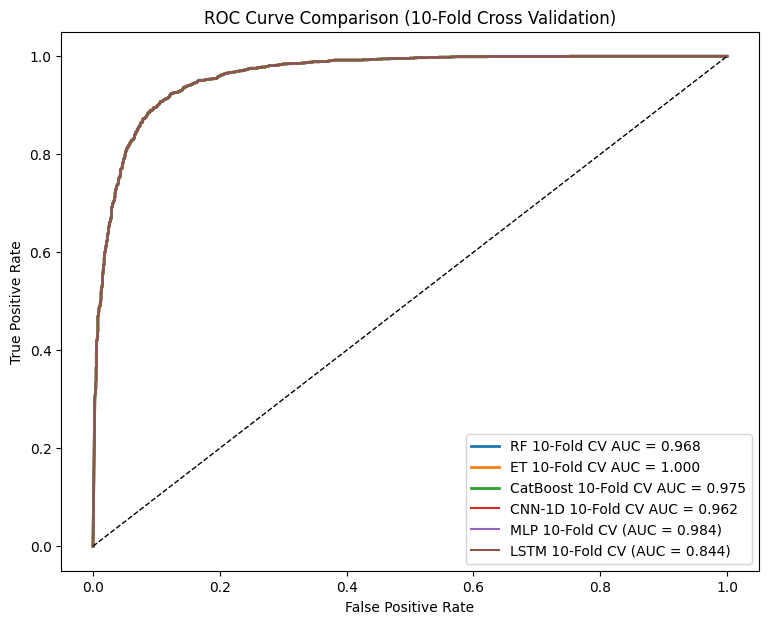

In [ ]:
plt.figure(figsize=(9,7))

# =========================
# MACHINE LEARNING MODELS
# =========================
# plt.plot(fpr_rf, tpr_rf, lw=2,
#          label=f"RF 10-Fold CV AUC = {rf_roc_auc:.3f}")

# plt.plot(fpr_et, tpr_et, lw=2,
#          label=f"ET 10-Fold CV AUC = {et_roc_auc:.3f}")

# plt.plot(fpr_cat, tpr_cat, lw=2,
#          label=f"CatBoost 10-Fold CV AUC = {cat_roc_auc:.3f}")

# # =========================
# # DEEP LEARNING MODELS
# # =========================
# plt.plot(fpr_cnn, tpr_cnn, lw=2,
#          label=f"CNN1D 10-Fold CV AUC = {CNN1D_roc_auc:.3f}")

# plt.plot(fpr_mlp, tpr_mlp, lw=2,
#          label=f"MLP1D 10-Fold CV AUC = {MLP1D_roc_auc:.3f}")

# plt.plot(fpr_lstm, tpr_lstm, lw=2,
#          label=f"LSTM1D 10-Fold CV AUC = {LSTM1D_roc_auc:.3f}")

plt.plot(fpr, tpr, lw=2, label=f'RF 10-Fold CV AUC = {rf_roc_auc:.3f}')
plt.plot(fpr, tpr, lw=2, label=f'ET 10-Fold CV AUC = {et_roc_auc:.3f}')
plt.plot(fpr, tpr, lw=2, label=f'CatBoost 10-Fold CV AUC = {cat_roc_auc:.3f}')
plt.plot(fpr, tpr, label=f"CNN-1D 10-Fold CV AUC = {CNN1D_roc_auc:.3f}")
plt.plot(fpr, tpr, label=f'MLP 10-Fold CV (AUC = {MLP1D_roc_auc:.3f})')
plt.plot(fpr, tpr, label=f'LSTM 10-Fold CV (AUC = {LSTM1D_roc_auc:.3f})')






# =========================
# RANDOM LINE
# =========================
plt.plot([0,1], [0,1], 'k--', lw=1)

# =========================
# LABELS & TITLE
# =========================
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (10-Fold Cross Validation)")

plt.legend(loc="lower right")

plt.show()

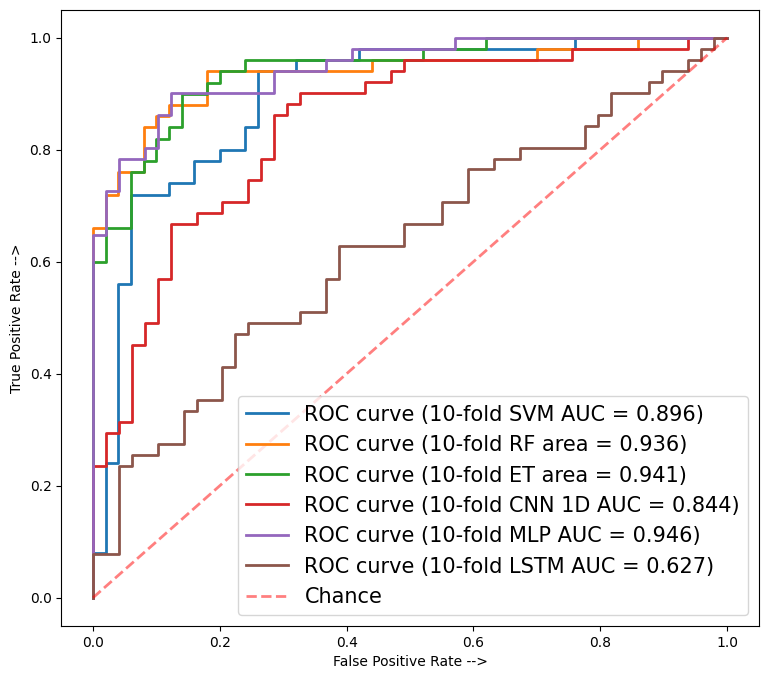

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score


plt.figure(figsize=(9,8))

plt.plot(fpr_indep, tpr_indep, lw=2, label='ROC curve (10-fold SVM AUC = %0.3f)' % roc_auc_indep)
plt.plot(fpr_test, tpr_test, lw=2, label='ROC curve (10-fold RF area = %0.3f)' % roc_auc_test)
plt.plot(etc_fpr_test, etc_tpr_test, lw=2, label='ROC curve (10-fold ET area = %0.3f)' % etc_roc_auc_test)
plt.plot(cnn_model2_fpr, cnn_model2_tpr, lw=2, label='ROC curve (10-fold CNN 1D AUC = %0.3f)' % cnn_model2_auc)
plt.plot(mlp_fpr, mlp_tpr, lw=2, label='ROC curve (10-fold MLP AUC = %0.3f)' % mlp_auc)
plt.plot(lstm_fpr, lstm_tpr, lw=2, label='ROC curve (10-fold LSTM AUC = %0.3f)' % lstm_auc)

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.5)
#plt.plot([0, 1], [0, 1],  lw=2, color="r", label="Amino Acid Composition ROC Curve", alpha=0.8)

plt.xlabel('False Positive Rate -->')
plt.ylabel('True Positive Rate -->')

plt.legend(loc="lower right", fontsize=15, ncol=1)

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


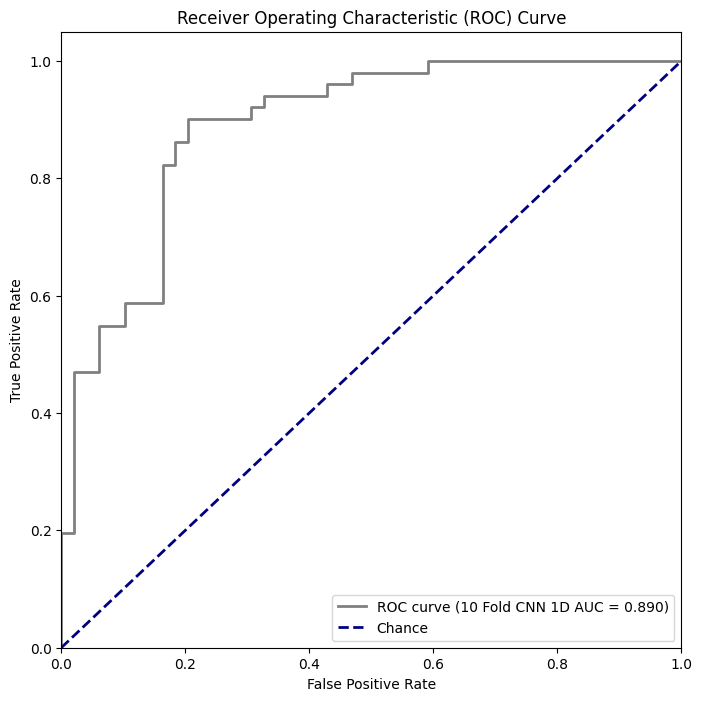

0.8903561424569828


In [ ]:
#predict_classes=np.argmax(predict_prob,axis=1)
from sklearn.metrics import roc_curve, roc_auc_score
probs_cnn_model2=CNN1D.predict(X_test)
# calculate roc curves
cnn_model2_probs = probs_cnn_model2
cnn_model2_probs = cnn_model2_probs[:, 0]
cnn_model2_auc = roc_auc_score(Y_test, cnn_model2_probs)
cnn_model2_fpr, cnn_model2_tpr, threshold = roc_curve(Y_test, cnn_model2_probs)
plt.figure(figsize=(8,8))

#plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="r", label="Chance", alpha=0.8)
plt.plot(cnn_model2_fpr, cnn_model2_tpr, color='Grey', lw=2, label='ROC curve (10 Fold CNN 1D AUC = %0.3f)' % cnn_model2_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, label="Chance" ,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
#plt.plot(lstm_fpr, lstm_tpr, marker='.', label='LSTM' % lstm_auc)
print(cnn_model2_auc)

Training MLP1D with 10-Fold CV...

Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Fold 3


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Fold 10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


MLP1D model saved as MLP1D_model.h5!

===== MLP1D 10-FOLD CV RESULTS =====
Accuracy: 89.352678571%
F1 Score: 88%
Precision: 89.835929211%
Sensitivity (Recall): 87.262387714%
Specificity: 91.080461693%
MCC: 0.791561757
Confusion Matrix:
 [[2227  218]
 [ 259 1776]]


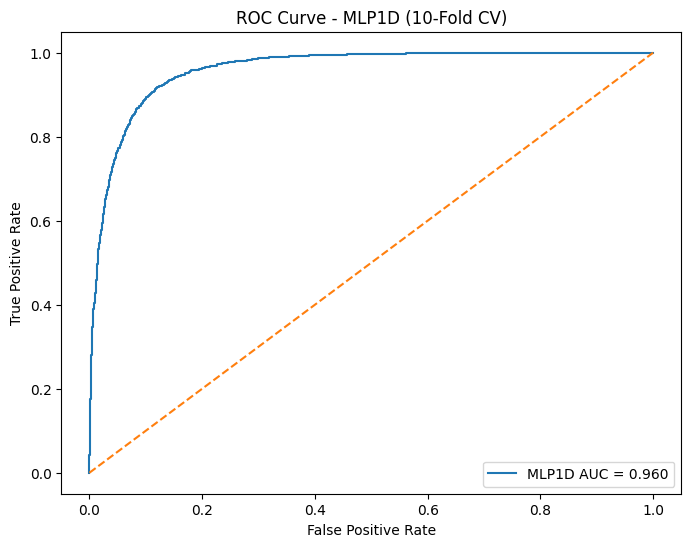

In [ ]:
# =========================
# 2. MODEL PATH
# =========================
model_path = "MLP1D_model_10fold.h5"

# =========================
# 3. INITIALIZE METRICS
# =========================
accuracy_list, f1_list, precision_list = [], [], []
recall_list, specificity_list, mcc_list = [], [], []
conf_matrix_total = np.array([[0, 0], [0, 0]])

# ROC storage
all_y_true = []
all_y_scores = []

# =========================
# 4. STRATIFIED K-FOLD
# =========================
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# =========================
# 5. LOAD OR TRAIN MODEL
# =========================
if os.path.exists(model_path):
    print("Loading saved MLP1D model...")
    MLP1D = load_model(model_path)
    print("Model loaded. Skipping training.")

else:
    print("Training MLP1D with 10-Fold CV...")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, Y), 1):

        print(f"\nFold {fold}")

        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]

        # =========================
        # BUILD MLP MODEL
        # =========================
        MLP1D = Sequential([
            Dense(256, activation='relu', input_shape=(X.shape[1],)),
            Dropout(0.3),

            Dense(128, activation='relu'),
            Dropout(0.3),

            Dense(64, activation='relu'),
            Dropout(0.2),

            Dense(1, activation='sigmoid')
        ])

        MLP1D.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        # =========================
        # TRAIN
        # =========================
        MLP1D.fit(
            X_train, Y_train,
            epochs=30,          # balanced speed + performance
            batch_size=32,
            verbose=0
        )

        # =========================
        # PREDICTION
        # =========================
        Y_prob = MLP1D.predict(X_test).ravel()
        Y_pred = (Y_prob > 0.5).astype(int)

        # Store ROC data
        all_y_true.extend(Y_test)
        all_y_scores.extend(Y_prob)

        # =========================
        # METRICS
        # =========================
        cm = confusion_matrix(Y_test, Y_pred)
        tn, fp, fn, tp = cm.ravel()

        accuracy_list.append(accuracy_score(Y_test, Y_pred))
        f1_list.append(f1_score(Y_test, Y_pred))
        precision_list.append(precision_score(Y_test, Y_pred))

        recall = recall_score(Y_test, Y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        mcc = matthews_corrcoef(Y_test, Y_pred)

        recall_list.append(recall)
        specificity_list.append(specificity)
        mcc_list.append(mcc)

        conf_matrix_total += cm

    # =========================
    # SAVE FINAL MODEL
    # =========================
    MLP1D.save(model_path)
    print("MLP1D model saved as MLP1D_model.h5!")

# =========================
# 6. PRINT RESULTS
# =========================
print("\n===== MLP1D 10-FOLD CV RESULTS =====")
print(f"Accuracy: {np.mean(accuracy_list)*100:.9f}%")
print(f"F1 Score: {np.mean(f1_list)*100:.0f}%")
print(f"Precision: {np.mean(precision_list)*100:.9f}%")
print(f"Sensitivity (Recall): {np.mean(recall_list)*100:.9f}%")
print(f"Specificity: {np.mean(specificity_list)*100:.9f}%")
print(f"MCC: {np.mean(mcc_list):.9f}")
print("Confusion Matrix:\n", conf_matrix_total)

# =========================
# 7. ROC CURVE (CORRECT)
# =========================
fpr, tpr, _ = roc_curve(all_y_true, all_y_scores)
mlp1d_roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"MLP1D AUC = {mlp1d_roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP1D (10-Fold CV)")
plt.legend()
plt.show()